In [6]:
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c("DESeq2", "airway", "ggplot2", "pheatmap", "EnhancedVolcano"), ask = FALSE)

library(DESeq2)
library(airway)
library(ggplot2)
library(pheatmap)
library(EnhancedVolcano)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'airway' 'ggplot2' 'pheatmap'
  'EnhancedVolcano'”
Old packages: 'textshaping'

Warning message in install.packages(update[instlib == l, "Package"], l, contriburl = contriburl, :
“installation of package ‘textshaping’ had non-zero exit status”


In [7]:
data("airway")
se <- airway

In [8]:
se$dex <- relevel(factor(se$dex), ref = "untrt")
colData(se)

DataFrame with 8 rows and 9 columns
           SampleName     cell      dex    albut        Run avgLength
             <factor> <factor> <factor> <factor>   <factor> <integer>
SRR1039508 GSM1275862  N61311     untrt    untrt SRR1039508       126
SRR1039509 GSM1275863  N61311     trt      untrt SRR1039509       126
SRR1039512 GSM1275866  N052611    untrt    untrt SRR1039512       126
SRR1039513 GSM1275867  N052611    trt      untrt SRR1039513        87
SRR1039516 GSM1275870  N080611    untrt    untrt SRR1039516       120
SRR1039517 GSM1275871  N080611    trt      untrt SRR1039517       126
SRR1039520 GSM1275874  N061011    untrt    untrt SRR1039520       101
SRR1039521 GSM1275875  N061011    trt      untrt SRR1039521        98
           Experiment    Sample    BioSample
             <factor>  <factor>     <factor>
SRR1039508  SRX384345 SRS508568 SAMN02422669
SRR1039509  SRX384346 SRS508567 SAMN02422675
SRR1039512  SRX384349 SRS508571 SAMN02422678
SRR1039513  SRX384350 SRS508572 SAMN024

In [9]:
dds <- DESeqDataSet(se, design = ~ cell + dex)
dds <- dds[rowSums(counts(dds)) >= 10, ]  # Filter low counts
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [10]:
res <- results(dds, contrast = c("dex", "trt", "untrt"))
res <- res[order(res$padj), ]
summary(res)


out of 22369 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 2610, 12%
LFC < 0 (down)     : 2224, 9.9%
outliers [1]       : 0, 0%
low counts [2]     : 4337, 19%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [11]:
sig <- subset(res, padj < 0.05 & abs(log2FoldChange) > 1)
cat("Significant DEGs:", nrow(sig), "\n")
head(sig, 10)

Significant DEGs: 1018 


log2 fold change (MLE): dex trt vs untrt 
Wald test p-value: dex trt vs untrt 
DataFrame with 10 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat       pvalue
                <numeric>      <numeric> <numeric> <numeric>    <numeric>
ENSG00000152583   997.445        4.57497 0.1842414   24.8314 4.11067e-136
ENSG00000165995   495.096        3.29110 0.1330527   24.7353 4.46338e-135
ENSG00000120129  3409.038        2.94785 0.1218764   24.1872 3.03384e-129
ENSG00000101347 12703.413        3.76702 0.1559919   24.1488 7.68266e-129
ENSG00000189221  2341.781        3.35365 0.1421810   23.5872 5.21271e-123
ENSG00000211445 12285.700        3.73044 0.1663984   22.4187 2.58506e-111
ENSG00000157214  3009.273        1.97680 0.0904251   21.8611 6.09135e-106
ENSG00000162614  5393.115        2.03570 0.0946847   21.4997 1.56546e-102
ENSG00000125148  3656.267        2.21101 0.1060906   20.8407  1.84964e-96
ENSG00000154734 30315.113        2.34563 0.1163596   20.1585  2.26676e

using ntop=500 top features by variance



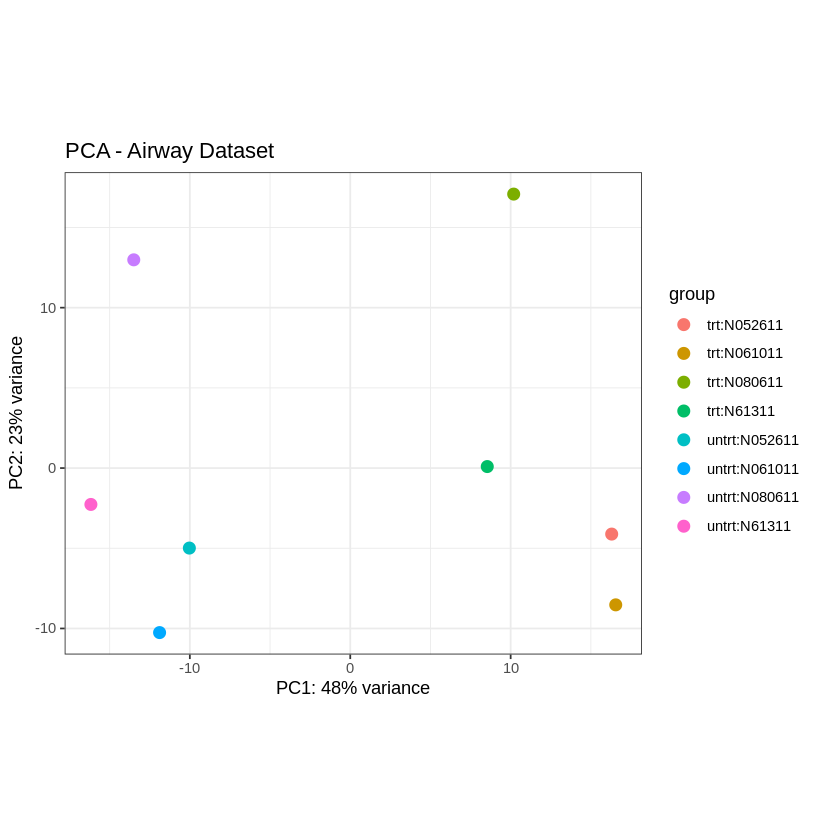

In [12]:
vsd <- vst(dds, blind = FALSE)
plotPCA(vsd, intgroup = c("dex", "cell")) +
  ggtitle("PCA - Airway Dataset") +
  theme_bw()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


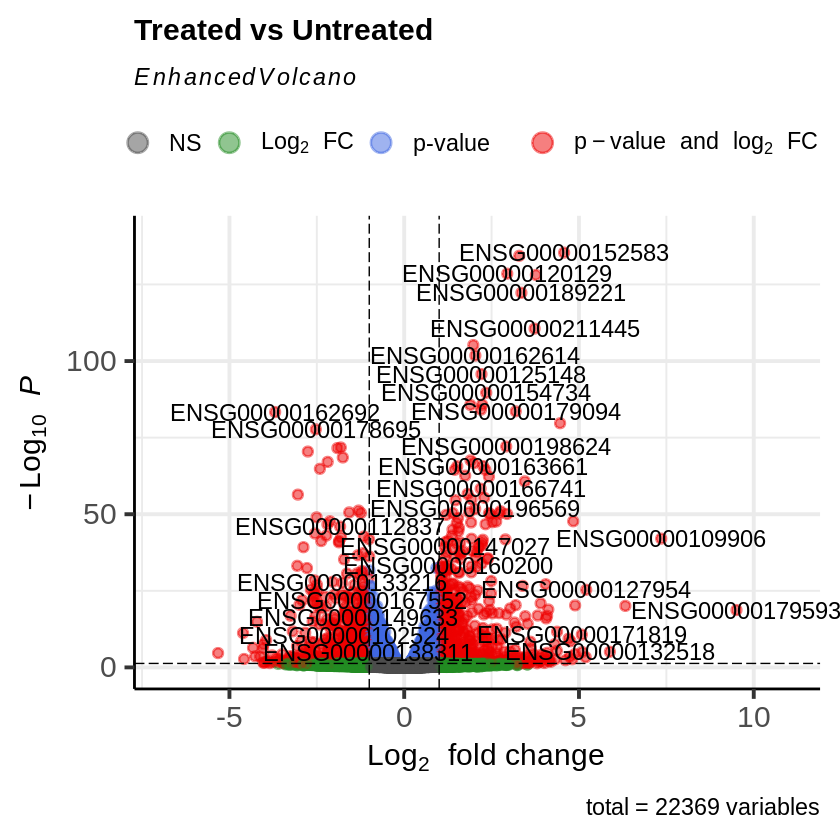

In [13]:
EnhancedVolcano(as.data.frame(res),
  lab    = rownames(res),
  x      = "log2FoldChange",
  y      = "pvalue",
  title  = "Treated vs Untreated",
  pCutoff = 0.05,
  FCcutoff = 1)

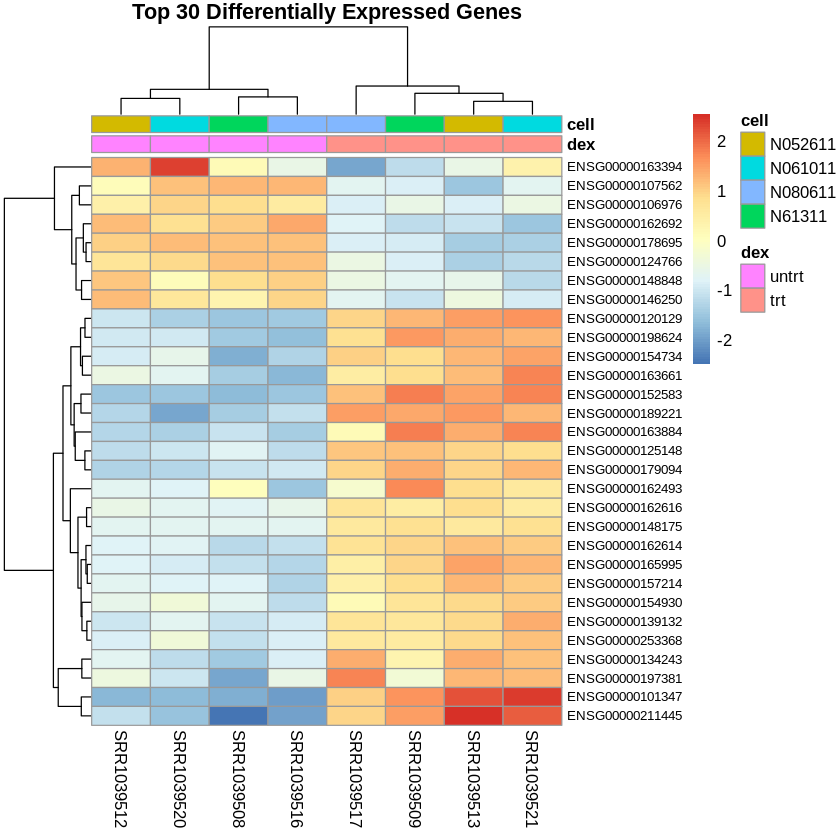

In [14]:
top30 <- head(rownames(sig), 30)
mat   <- assay(vsd)[top30, ]
mat   <- mat - rowMeans(mat)

annotation <- as.data.frame(colData(vsd)[, c("dex", "cell")])
pheatmap(mat,
  annotation_col = annotation,
  show_rownames  = TRUE,
  fontsize_row   = 8,
  main           = "Top 30 Differentially Expressed Genes")

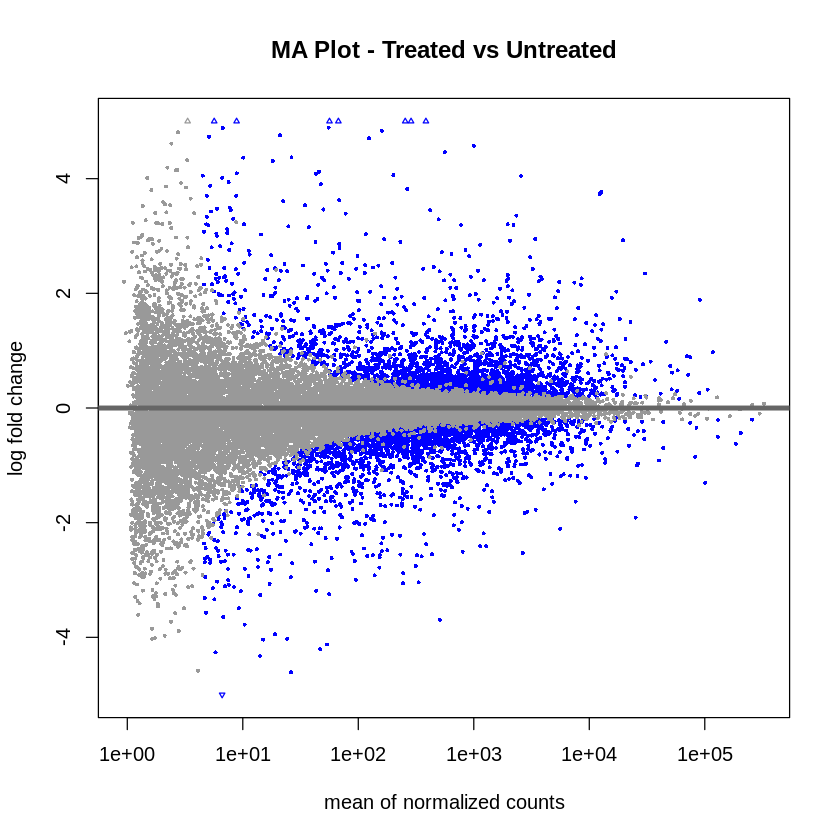

In [15]:
plotMA(res, ylim = c(-5, 5), main = "MA Plot - Treated vs Untreated")

In [16]:
write.csv(as.data.frame(res), "DESeq2_all_results.csv")
write.csv(as.data.frame(sig), "DESeq2_significant_DEGs.csv")